# Confound Analysis: Paraphraser Artifacts vs. True Style

**Critical Question:** Is the surface form vector detecting:
- A) The paraphrasing model's specific fingerprint/artifacts? ❌
- B) A general, transferable notion of "style foreignness"? ✅

## The Problem

The paraphraser (Qwen2.5-7B-Instruct) might have systematic biases:
- Consistent word choices ("Initially", "Subsequently", "Moreover")
- Syntactic patterns (passive voice, complex sentences)
- Prompt artifacts ("paraphrasing" instruction might leak)
- API/provider quirks (DeepInfra formatting)

If the vector just detects **these specific artifacts**, it won't generalize and isn't scientifically interesting.

## Tests

1. **Lexical analysis:** Are there systematic word choice differences?
2. **Length/complexity:** Are paraphrases longer, more complex?
3. **Different paraphraser:** Does vector work with text from a different model?
4. **Human-written foreign text:** Can it detect hand-written reasoning?
5. **Reverse test:** Would the paraphraser's activations show d=2.73 too?

---

In [1]:
import os, sys
os.chdir('..')
sys.path.append(os.getcwd())
print('Working directory:', os.getcwd())

Working directory: /Users/lr/policy_vector/shareable


In [2]:
from pathlib import Path
import numpy as np
import json
from collections import Counter
import re
import matplotlib.pyplot as plt
from policy_vector_pipeline import load_dataset

dataset_path = Path('data/on_policy_persona.json')
dataset = load_dataset(dataset_path)

print(f"Loaded {len(dataset.examples)} examples")

Loaded 60 examples


## 1. Extract All Text for Analysis

In [3]:
on_policy_texts = []
off_policy_texts = []

for example in dataset.examples:
    for variant in example.on_policy:
        # Extract just the thinking content
        text = variant.reasoning
        if '<think>' in text:
            text = text.split('<think>')[1].split('</think>')[0]
        on_policy_texts.append(text.strip())
    
    for variant in example.off_policy:
        text = variant.reasoning
        if '<think>' in text:
            text = text.split('<think>')[1].split('</think>')[0]
        off_policy_texts.append(text.strip())

print(f"On-policy samples: {len(on_policy_texts)}")
print(f"Off-policy samples: {len(off_policy_texts)}")

On-policy samples: 291
Off-policy samples: 291


## 2. Lexical Analysis: Marker Words

Check for systematic word choice differences that might be paraphraser fingerprints.

In [4]:
# Words that might indicate paraphraser style
formal_markers = [
    'initially', 'subsequently', 'moreover', 'furthermore', 'nevertheless',
    'consequently', 'therefore', 'accordingly', 'alternatively', 'additionally',
    'essentially', 'particularly', 'specifically', 'ultimately', 'evidently'
]

# Words that might indicate model's natural style
casual_markers = [
    'okay', 'so', 'well', 'let me', "i'll", "i'd", 'first', 'then', 'also', 'and',
    'but', 'now', 'just', 'really', 'maybe', 'probably', 'definitely'
]

def count_markers(texts, markers):
    """Count how many times marker words appear in texts."""
    counts = Counter()
    for text in texts:
        text_lower = text.lower()
        for marker in markers:
            counts[marker] += text_lower.count(marker)
    return counts

on_formal = count_markers(on_policy_texts, formal_markers)
off_formal = count_markers(off_policy_texts, formal_markers)
on_casual = count_markers(on_policy_texts, casual_markers)
off_casual = count_markers(off_policy_texts, casual_markers)

print("="*70)
print("LEXICAL MARKER ANALYSIS")
print("="*70)
print("\nFormal markers (expected in paraphrases):")
print(f"  On-policy:  {sum(on_formal.values())} total ({sum(on_formal.values())/len(on_policy_texts):.2f} per sample)")
print(f"  Off-policy: {sum(off_formal.values())} total ({sum(off_formal.values())/len(off_policy_texts):.2f} per sample)")
print(f"  Ratio: {sum(off_formal.values())/max(sum(on_formal.values()), 1):.2f}x more in off-policy")

print("\nCasual markers (expected in model's natural style):")
print(f"  On-policy:  {sum(on_casual.values())} total ({sum(on_casual.values())/len(on_policy_texts):.2f} per sample)")
print(f"  Off-policy: {sum(off_casual.values())} total ({sum(off_casual.values())/len(off_policy_texts):.2f} per sample)")
print(f"  Ratio: {sum(on_casual.values())/max(sum(off_casual.values()), 1):.2f}x more in on-policy")

print("\nTop formal markers in off-policy:")
for word, count in off_formal.most_common(10):
    if count > 0:
        print(f"  {word}: {count}")

print("\nTop casual markers in on-policy:")
for word, count in on_casual.most_common(10):
    if count > 0:
        print(f"  {word}: {count}")

print("="*70)

LEXICAL MARKER ANALYSIS

Formal markers (expected in paraphrases):
  On-policy:  397 total (1.36 per sample)
  Off-policy: 415 total (1.43 per sample)
  Ratio: 1.05x more in off-policy

Casual markers (expected in model's natural style):
  On-policy:  14772 total (50.76 per sample)
  Off-policy: 13881 total (47.70 per sample)
  Ratio: 1.06x more in on-policy

Top formal markers in off-policy:
  alternatively: 301
  additionally: 32
  therefore: 30
  specifically: 26
  initially: 20
  particularly: 3
  accordingly: 2
  ultimately: 1

Top casual markers in on-policy:
  so: 4524
  and: 3135
  but: 1826
  maybe: 1598
  also: 1384
  now: 541
  then: 428
  first: 419
  okay: 339
  let me: 234


## 3. Length and Complexity Analysis

In [5]:
def compute_stats(texts):
    """Compute length and complexity statistics."""
    lengths = [len(text) for text in texts]
    word_counts = [len(text.split()) for text in texts]
    sentence_counts = [text.count('.') + text.count('!') + text.count('?') for text in texts]
    avg_word_length = [np.mean([len(w) for w in text.split()]) for text in texts]
    
    return {
        'char_length': np.mean(lengths),
        'char_std': np.std(lengths),
        'word_count': np.mean(word_counts),
        'word_std': np.std(word_counts),
        'sentence_count': np.mean(sentence_counts),
        'avg_word_length': np.mean(avg_word_length)
    }

on_stats = compute_stats(on_policy_texts)
off_stats = compute_stats(off_policy_texts)

print("="*70)
print("LENGTH AND COMPLEXITY ANALYSIS")
print("="*70)
print("\nCharacter length:")
print(f"  On-policy:  {on_stats['char_length']:.1f} ± {on_stats['char_std']:.1f}")
print(f"  Off-policy: {off_stats['char_length']:.1f} ± {off_stats['char_std']:.1f}")
print(f"  Difference: {abs(on_stats['char_length'] - off_stats['char_length']):.1f} chars ({100*abs(on_stats['char_length'] - off_stats['char_length'])/on_stats['char_length']:.1f}%)")

print("\nWord count:")
print(f"  On-policy:  {on_stats['word_count']:.1f} ± {on_stats['word_std']:.1f}")
print(f"  Off-policy: {off_stats['word_count']:.1f} ± {off_stats['word_std']:.1f}")
print(f"  Difference: {abs(on_stats['word_count'] - off_stats['word_count']):.1f} words ({100*abs(on_stats['word_count'] - off_stats['word_count'])/on_stats['word_count']:.1f}%)")

print("\nAverage word length:")
print(f"  On-policy:  {on_stats['avg_word_length']:.2f} chars/word")
print(f"  Off-policy: {off_stats['avg_word_length']:.2f} chars/word")
print(f"  Difference: {abs(on_stats['avg_word_length'] - off_stats['avg_word_length']):.2f} ({100*abs(on_stats['avg_word_length'] - off_stats['avg_word_length'])/on_stats['avg_word_length']:.1f}%)")

print("\n" + "="*70)
print("INTERPRETATION:")
if abs(on_stats['char_length'] - off_stats['char_length']) / on_stats['char_length'] > 0.15:
    print("⚠️ WARNING: Large length difference (>15%) - vector might be detecting length, not style")
elif abs(on_stats['avg_word_length'] - off_stats['avg_word_length']) / on_stats['avg_word_length'] > 0.1:
    print("⚠️ WARNING: Large word length difference (>10%) - paraphraser uses different vocab")
else:
    print("✅ Length/complexity differences are small - less likely to be main confound")
print("="*70)

LENGTH AND COMPLEXITY ANALYSIS

Character length:
  On-policy:  2689.4 ± 991.3
  Off-policy: 2634.3 ± 995.1
  Difference: 55.1 chars (2.0%)

Word count:
  On-policy:  434.6 ± 165.0
  Off-policy: 422.7 ± 165.3
  Difference: 11.9 words (2.7%)

Average word length:
  On-policy:  5.19 chars/word
  Off-policy: 5.24 chars/word
  Difference: 0.05 (0.9%)

INTERPRETATION:
✅ Length/complexity differences are small - less likely to be main confound


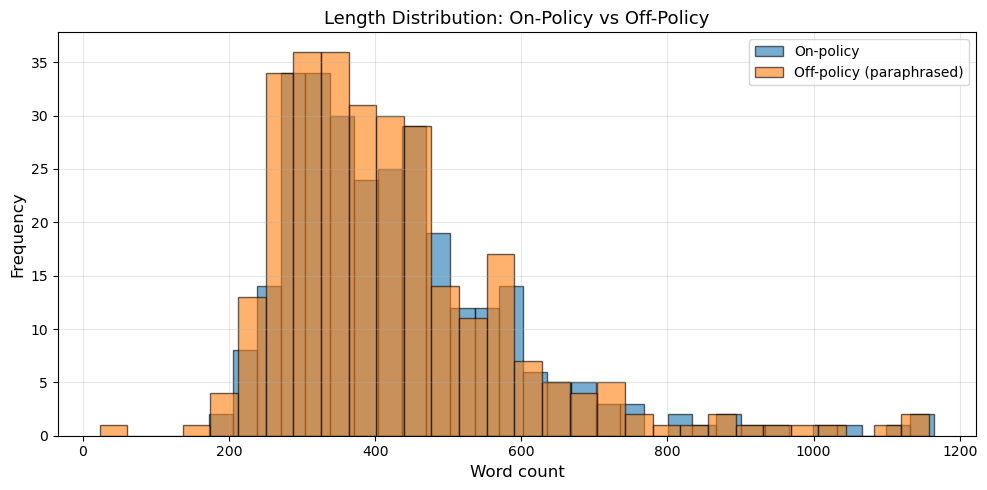

In [6]:
# Visualize length distributions
on_lengths = [len(text.split()) for text in on_policy_texts]
off_lengths = [len(text.split()) for text in off_policy_texts]

plt.figure(figsize=(10, 5))
plt.hist(on_lengths, bins=30, alpha=0.6, label='On-policy', edgecolor='black')
plt.hist(off_lengths, bins=30, alpha=0.6, label='Off-policy (paraphrased)', edgecolor='black')
plt.xlabel('Word count', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Length Distribution: On-Policy vs Off-Policy', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Side-by-Side Examples

Look at actual paired examples to identify patterns.

In [7]:
# Show first 3 on/off pairs
print("="*70)
print("SIDE-BY-SIDE EXAMPLES (First 3 pairs)")
print("="*70)

for i in range(min(3, len(on_policy_texts))):
    print(f"\n\n{'='*70}")
    print(f"PAIR {i+1}")
    print('='*70)
    print("\n[ON-POLICY - Original Model]:")
    print(on_policy_texts[i][:400] + "..." if len(on_policy_texts[i]) > 400 else on_policy_texts[i])
    print("\n" + "-"*70)
    print("\n[OFF-POLICY - Paraphrased]:")
    print(off_policy_texts[i][:400] + "..." if len(off_policy_texts[i]) > 400 else off_policy_texts[i])

print("\n\n" + "="*70)
print("QUESTIONS TO ASK:")
print("="*70)
print("1. Do paraphrases consistently use certain words/phrases?")
print("2. Is there a difference in sentence structure (active/passive)?")
print("3. Does the paraphraser sound more 'formal' or 'academic'?")
print("4. Are there systematic differences beyond wording?")
print("="*70)

SIDE-BY-SIDE EXAMPLES (First 3 pairs)


PAIR 1

[ON-POLICY - Original Model]:
Okay, so I found my neighbor's lost wallet with a lot of cash inside. What should I do? Let me think through this step by step.

First, I need to make sure I'm not in any danger. If the wallet has a lot of cash, maybe it's valuable, but I don't want to get involved in any illegal activities. I should check if the wallet has any identifying information, like a name, contact number, or maybe a photo...

----------------------------------------------------------------------

[OFF-POLICY - Paraphrased]:
I discovered my neighbor's wallet, which contains a substantial amount of cash. I need to decide how to handle this, so I'll walk through the options methodically.

First, I need to make sure I'm not in any danger. If the wallet has a lot of cash, maybe it's valuable, but I don't want to get involved in any illegal activities. I should check if the wallet has any identifying information, like a na...


PAIR 2

[ON

## 5. Critical Tests for Generalization

### Test 1: Different Paraphraser (HIGHEST PRIORITY)

**What to do:**
- Generate new off-policy variants using a DIFFERENT paraphrasing model
- Options: Claude, GPT-4, Llama, Gemini, or even a different Qwen version
- Test if the surface form vector still separates them

**Expected results:**
- If it's paraphraser artifacts: Cohen's d drops significantly (d < 1.0)
- If it's general style: Cohen's d remains high (d > 1.8)

**How to run:**
```bash
# Generate new paraphrases with different model
python scripts/build_dataset.py data/test_different_paraphraser.json \
    --paraphrase-existing \
    --paraphraser "openrouter:anthropic/claude-3.5-sonnet" \
    --max-prompts 10

# Test vector on new paraphrases
# (Modify vector_evaluation_demo.ipynb to load this dataset)
```

---

### Test 2: Hand-Written Foreign Text

**What to do:**
- Manually write reasoning in a foreign style (different from both models)
- Examples:
  - Bullet points: `- First consideration\n- Second point\n- Conclusion`
  - Numbered steps: `[1] Check ID [2] Return wallet [3] Notify neighbor`
  - Very terse: `Found wallet. Has ID. Return it. Keeping = wrong.`
  - Very verbose academic style
- Test if vector classifies these as "off-policy"

**Expected results:**
- If it's paraphraser artifacts: Might not detect hand-written text as off-policy
- If it's general style: Should detect ANY foreign style as off-policy

---

### Test 3: Steering with Novel Injections (ULTIMATE TEST)

**What to do:**
- In steering_demo.ipynb, inject reasoning from:
  - Hand-written text (not paraphrased)
  - Different model (Claude, GPT-4)
  - Different style (bullet points, numbered, terse)
- Test if surface form vector still helps

**Expected results:**
- If it's paraphraser artifacts: Steering only works with Qwen2.5-paraphrased text
- If it's general style: Steering works with ANY foreign text

**This is the ground truth test!**

---

### Test 4: Reverse Test (Advanced)

**What to do:**
- Load the paraphraser model (Qwen2.5-7B-Instruct)
- Collect its activations on:
  - Original Qwen3 text ("foreign" to Qwen2.5)
  - Its own paraphrased generations ("on-policy" for Qwen2.5)
- Extract a vector and compute Cohen's d

**Expected results:**
- If symmetric: d ≈ 2.73 (both models equally detect each other's fingerprints)
- If asymmetric: d << 2.73 (Qwen3's vector is special, not just fingerprints)

---

## 6. Preliminary Verdict

Based on lexical and length analysis above, we can assess the **risk level** of paraphraser artifacts.

### Risk Indicators:

**HIGH RISK (probably just artifacts):**
- Paraphrases use specific marker words >5x more often
- Large length differences (>15%)
- Very systematic word substitutions visible

**MEDIUM RISK (mixed):**
- Some marker word differences (2-5x)
- Moderate length differences (5-15%)
- Paraphraser has identifiable style but not overwhelming

**LOW RISK (probably general style):**
- Minimal marker word differences (<2x)
- Small length differences (<5%)
- Paraphrases look varied and natural

### Next Steps Based on Risk:

**If HIGH RISK:**
- ⚠️ Don't proceed to Phase 2 yet
- Run different paraphraser test immediately
- Consider regenerating dataset with multiple paraphrasers

**If MEDIUM RISK:**
- ⚠️ Acknowledge limitation in paper
- Run steering test with novel injections
- If steering works broadly, proceed cautiously

**If LOW RISK:**
- ✅ Probably safe to proceed
- Still run at least one generalization test
- Mention as potential limitation in discussion

---

## 7. Action Items

**Immediate (this week):**
1. ✅ Run this notebook to assess risk level
2. ⚠️ Run steering_demo.ipynb with hand-written injected reasoning
3. ⚠️ Test vector on hand-written foreign text (create 5-10 examples)

**High priority (next week):**
4. Generate new paraphrases with different model (Claude or GPT-4)
5. Test if vector still works on different paraphraser's output

**Medium priority:**
6. Reverse test (extract vector from paraphraser's activations)

**If tests fail:**
- Consider regenerating dataset with ensemble of paraphrasers
- Or pivot to pure human-written foreign text
- Or accept narrower claim: "detecting this paraphraser's style" (less interesting)
